En esta libreta se exploran los conjuntos de datos con los que se cuenta actualmente. Además, se propone una forma de unificarlos.

A continuación se listan los datasets disponibles: 

In [1]:
from pathlib import Path

In [2]:
base_dir = Path().resolve().parents[1]
data_dir = base_dir / "data"
raw_dir = data_dir / "raw"

assert raw_dir.exists() and raw_dir.is_dir()

for item in raw_dir.glob("*.csv"):
    item_size_mb = item.stat().st_size / 1024 ** 2
    print(item.relative_to(base_dir), f'{item_size_mb:.2f} mb') 

data/raw/pobreza_municipal.csv 2.95 mb
data/raw/incidencia_delictiva_municipal.csv 361.19 mb
data/raw/imm_2020-3.csv 0.53 mb
data/raw/incidencia_delictiva_estatal.csv 53.85 mb
data/raw/censo_iter_municipios_2020.csv 142.73 mb
data/raw/pobreza_municipal_2020.csv 0.55 mb
data/raw/indicadores_laborales_municipios.csv 0.34 mb


Definimos las rutas a los archivos:

In [37]:
dellitos_mun_path = raw_dir / "incidencia_delictiva_municipal.csv"
imm_path = raw_dir / "imm_2020-3.csv"
censo_path = raw_dir / "censo_iter_municipios_2020.csv"
pobreza_path = raw_dir / "pobreza_municipal.csv"
laborales_path = raw_dir / "indicadores_laborales_municipios.csv"

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Incidencia delictiva

Este dataset contiene información sobre la incidencia delictiva a nivel municipal.

In [59]:
delitos = pd.read_csv(dellitos_mun_path, encoding_errors='ignore')
delitos.head()

,Ao,Clave_Ent,Entidad,Cve. Municipio,Municipio,Bien jurdico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,...,1,1,0,1,1,0,2,1,0,1
1,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,...,0,0,0,1,0,1,0,0,0,0
2,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,...,1,1,3,2,0,1,2,0,0,0
3,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,1,...,0,1,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,...,0,0,1,0,0,0,0,0,0,0


* Se han omitidos los errores de encoding. 

In [60]:
delitos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2562994 entries, 0 to 2562993
Data columns (total 21 columns):
 #   Column                 Dtype
---  ------                 -----
 0   Ao                     int64
 1   Clave_Ent              int64
 2   Entidad                str  
 3   Cve. Municipio         int64
 4   Municipio              str  
 5   Bien jurdico afectado  str  
 6   Tipo de delito         str  
 7   Subtipo de delito      str  
 8   Modalidad              str  
 9   Enero                  int64
 10  Febrero                int64
 11  Marzo                  int64
 12  Abril                  int64
 13  Mayo                   int64
 14  Junio                  int64
 15  Julio                  int64
 16  Agosto                 int64
 17  Septiembre             int64
 18  Octubre                int64
 19  Noviembre              int64
 20  Diciembre              int64
dtypes: int64(15), str(6)
memory usage: 410.6 MB


* \~ 2 millones de registros
* 20 columnas 

In [61]:
delitos.Entidad.describe()

count     2562994
unique         32
top        Oaxaca
freq       510678
Name: Entidad, dtype: object

* 32 entidades
* `'Oaxaca'` entidad con mayor frecuencia

In [62]:
delitos.Municipio.describe()

count          2562994
unique            2337
top       Benito Jurez
freq              7546
Name: Municipio, dtype: object

* \~ 2300 municios (**información importante**)
* `'Benito Juarez'` mpio con mayor frecuencia

In [63]:
delitos['Bien jurdico afectado'].describe()

count           2562994
unique                7
top       El patrimonio
freq            1098426
Name: Bien jurdico afectado, dtype: object

* 7 clases de `'Bien Jurídico Afectado'`
* `'EL patrimonio'` tipo de delito más frecuente

Las clases de bien jurídico afectado:

In [64]:
delitos['Bien jurdico afectado'].unique().tolist()

['La vida y la Integridad corporal',
 'Libertad personal',
 'La libertad y la seguridad sexual',
 'El patrimonio',
 'La familia',
 'La sociedad',
 'Otros bienes jurdicos afectados (del fuero comn)']

In [65]:
delitos['Bien jurdico afectado'].value_counts(normalize=True)

Bien jurdico afectado
El patrimonio                                       0.428571
La vida y la Integridad corporal                    0.244898
Otros bienes jurdicos afectados (del fuero comn)    0.102041
Libertad personal                                   0.081633
La libertad y la seguridad sexual                   0.071429
La familia                                          0.040816
La sociedad                                         0.030612
Name: proportion, dtype: float64

* `'El patrimonio'` domina los tipos deb bien jurídico con \~40\%. Le sigue `'La vida y la Integridad corporal'` con \~25\%.
* Los demás bienes jurídicos se reparten \~45\%. 

In [66]:
delitos['Tipo de delito'].describe()

count     2562994
unique         40
top          Robo
freq       941508
Name: Tipo de delito, dtype: object

* 40 tipos de delitos únicos
* `'Robo'` es el tipo de delito más frecuente

Los tipos de delitos únicos: 

In [67]:
delitos['Tipo de delito'].unique().tolist()

['Homicidio',
 'Lesiones',
 'Feminicidio',
 'Aborto',
 'Otros delitos que atentan contra la vida y la integridad corporal',
 'Secuestro',
 'Trfico de menores',
 'Rapto',
 'Otros delitos que atentan contra la libertad personal',
 'Abuso sexual',
 'Acoso sexual',
 'Hostigamiento sexual',
 'Violacin simple',
 'Violacin equiparada',
 'Incesto',
 'Otros delitos que atentan contra la libertad y la seguridad sexual',
 'Robo',
 'Fraude',
 'Abuso de confianza',
 'Extorsin',
 'Dao a la propiedad',
 'Despojo',
 'Otros delitos contra el patrimonio',
 'Violencia familiar',
 'Violencia de gnero en todas sus modalidades distinta a la violencia familiar',
 'Incumplimiento de obligaciones de asistencia familiar',
 'Otros delitos contra la familia',
 'Corrupcin de menores',
 'Trata de personas',
 'Otros delitos contra la sociedad',
 'Narcomenudeo',
 'Amenazas',
 'Allanamiento de morada',
 'Evasin de presos',
 'Falsedad',
 'Falsificacin',
 'Contra el medio ambiente',
 'Delitos cometidos por servidores pb

Los top 10 tipos de delitos más frecuentes: 

In [68]:
delitos['Tipo de delito'].value_counts(normalize=True)[:10]

Tipo de delito
Robo                                                                 0.367347
Homicidio                                                            0.091837
Lesiones                                                             0.091837
Secuestro                                                            0.051020
Feminicidio                                                          0.040816
Aborto                                                               0.010204
Otros delitos que atentan contra la vida y la integridad corporal    0.010204
Trfico de menores                                                    0.010204
Rapto                                                                0.010204
Otros delitos que atentan contra la libertad personal                0.010204
Name: proportion, dtype: float64

In [69]:
delitos['Subtipo de delito'].describe()

count                       2562994
unique                           55
top       Robo de vehculo automotor
freq                         156918
Name: Subtipo de delito, dtype: object

* 55 subtipos de delito
* `'Robo de vehculo automotor'` es el subtipo de delito con mayor frecuencia.

Los subtipos de delito:

Los top 10 subtipos de delitos más frecuntes: 

In [70]:
delitos['Subtipo de delito'].value_counts(normalize=True)[:5]

Subtipo de delito
Robo de vehculo automotor    0.061224
Robo de maquinaria           0.061224
Homicidio culposo            0.051020
Lesiones culposas            0.051020
Secuestro                    0.051020
Name: proportion, dtype: float64

In [71]:
delitos['Modalidad'].describe()

count           2562994
unique               59
top       Con violencia
freq             313836
Name: Modalidad, dtype: object

* 50 tipos de modalidad diferentes
* `'Con violencia'` es el tipo de modalidad más frecuente

Los top 5 tipos de modalidad más frecuentes: 

In [72]:
delitos['Modalidad'].value_counts(normalize=True)[:5]

Modalidad
Con violencia        0.122449
Sin violencia        0.122449
Con arma de fuego    0.051020
Con arma blanca      0.051020
Con otro elemento    0.051020
Name: proportion, dtype: float64

**Observación importante**

Cada fila reprecenta: 

> municipio + año + tipo de delito + subtipo + modalidad

Tenemos los delitos desagregados, por lo que hay que agregarlos para obtener el total de delitos por municipio cada año. 

La suma de los meses: 

In [73]:
delitos['total_anual'] = delitos.loc[:, 'Enero':'Diciembre'].sum(axis=1)  # sum over rows
delitos['total_anual'].head()

0    10
1     4
2    10
3     2
4     1
Name: total_anual, dtype: int64

Agregamos todo por municipio-anio: 

In [74]:
groupby_cols = [
    'Ao', 
    'Clave_Ent', 
    'Cve. Municipio', 
    'Entidad', 
    'Municipio'
]
delitos_mun_anual = delitos \
    .groupby(groupby_cols, as_index=False) \
    ['total_anual'] \
    .sum()

delitos_mun_anual.head()

,Ao,Clave_Ent,Cve. Municipio,Entidad,Municipio,total_anual
0,2015,1,1001,Aguascalientes,Aguascalientes,18800
1,2015,1,1002,Aguascalientes,Asientos,247
2,2015,1,1003,Aguascalientes,Calvillo,554
3,2015,1,1004,Aguascalientes,Coso,160
4,2015,1,1005,Aguascalientes,Jess Mara,1285


In [75]:
delitos_mun_anual.info()

<class 'pandas.DataFrame'>
RangeIndex: 26153 entries, 0 to 26152
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Ao              26153 non-null  int64
 1   Clave_Ent       26153 non-null  int64
 2   Cve. Municipio  26153 non-null  int64
 3   Entidad         26153 non-null  str  
 4   Municipio       26153 non-null  str  
 5   total_anual     26153 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.2 MB


* \~26K registros 

Verificamos registros duplicados: 

In [76]:
delitos_mun_anual.duplicated(subset=['Ao', 'Clave_Ent', 'Cve. Municipio']).sum()

np.int64(0)

* No hay datos duplicados

La distribución del total de delitos anual: 

In [77]:
delitos_mun_anual['total_anual'].describe()

count    26153.000000
mean       830.960502
std       3401.885754
min          0.000000
25%         13.000000
50%         58.000000
75%        268.000000
max      53995.000000
Name: total_anual, dtype: float64

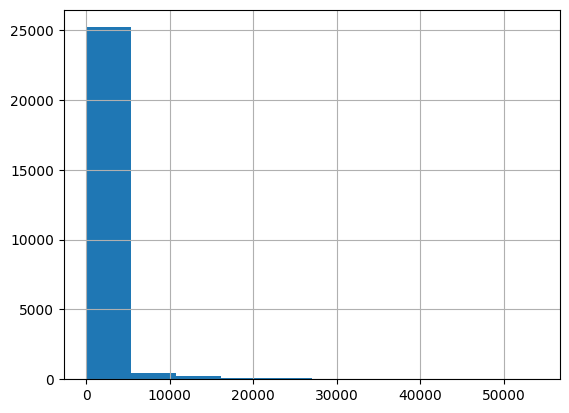

In [78]:
delitos_mun_anual['total_anual'].hist(); 

Los top 10 municipios con más delitos: 

In [79]:
delitos_mun_anual.sort_values('total_anual', ascending=False).head(10)

,Ao,Clave_Ent,Cve. Municipio,Entidad,Municipio,total_anual
18712,2023,2,2004,Baja California,Tijuana,53995
4432,2017,14,14039,Jalisco,Guadalajara,53153
6903,2018,14,14039,Jalisco,Guadalajara,52658
14,2015,2,2004,Baja California,Tijuana,52039
24017,2025,11,11020,Guanajuato,Len,51968
9374,2019,14,14039,Jalisco,Guadalajara,51075
21531,2024,11,11020,Guanajuato,Len,50207
3876,2017,2,2004,Baja California,Tijuana,50006
16569,2022,11,11020,Guanajuato,Len,49633
14090,2021,11,11020,Guanajuato,Len,49199


Es conveniente renombrear las columnas del conjunto agregado: 

In [92]:
column_names_delitos = [
    'anio', 
    'cve_ent',
    'cve_mun', 
    'ent', 
    'mpio', 
    'total_anual'
]

delitos_mun_anual.columns = column_names_delitos

In [82]:
delitos_mun_anual.head()

,anio,clave_ent,cve_mun,entidad,municipio,total_anual
0,2015,1,1001,Aguascalientes,Aguascalientes,18800
1,2015,1,1002,Aguascalientes,Asientos,247
2,2015,1,1003,Aguascalientes,Calvillo,554
3,2015,1,1004,Aguascalientes,Coso,160
4,2015,1,1005,Aguascalientes,Jess Mara,1285


In [83]:
del delitos

In [22]:
temp_dir = data_dir / "temp"
temp_dir.mkdir(exist_ok=True)

In [23]:
delitos_mun_anual.to_csv(temp_dir / "delitos_mun_anual.csv")

## Índice de marginación municipal

Este dataset comprende indicadores socioeconómicos e índice y grado de marginación por municipio.

Dado que el año es fijo (2020), las features seleccionadas serán constantes en el tiempo.

In [24]:
imm = pd.read_csv(imm_path)
imm.head()

,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,POB_TOT,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL.5000,PO2SM,IM_2020,GM_2020,IMN_2020
0,1,Aguascalientes,1001,Aguascalientes,948990,1.644738,20.367220,0.104799,0.113169,0.378610,0.591434,10.339530,7.523683,54.226594,60.318795,Muy bajo,0.944508
1,1,Aguascalientes,1002,Asientos,51536,3.526405,33.906364,2.650373,0.486448,0.858160,1.352430,22.942305,78.221049,78.565471,56.546071,Muy bajo,0.885433
2,1,Aguascalientes,1003,Calvillo,58250,4.491509,42.482450,0.365177,0.516760,0.800978,1.040411,19.219858,51.301288,79.259777,57.058251,Muy bajo,0.893453
3,1,Aguascalientes,1004,Cosío,17000,3.144867,27.696745,0.712855,0.577354,0.659833,1.030989,22.716866,65.470588,81.726369,57.114030,Muy bajo,0.894326
4,1,Aguascalientes,1005,Jesús María,129929,2.380588,26.692477,0.277034,0.354957,0.860426,1.312652,16.404575,37.164143,56.748753,59.011762,Muy bajo,0.924042


El total de municipios con información: 

In [42]:
len(imm.CVE_MUN.unique())

2469

* El total de municipios registrados es una cantidad similar a la del conjunto de incidencia delictiva. No habrá perdida de información al unir ambos datasets. 

In [28]:
imm.info()

<class 'pandas.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CVE_ENT   2469 non-null   int64  
 1   NOM_ENT   2469 non-null   str    
 2   CVE_MUN   2469 non-null   int64  
 3   NOM_MUN   2469 non-null   str    
 4   POB_TOT   2469 non-null   int64  
 5   ANALF     2469 non-null   float64
 6   SBASC     2469 non-null   float64
 7   OVSDE     2469 non-null   float64
 8   OVSEE     2469 non-null   float64
 9   OVSAE     2469 non-null   float64
 10  OVPT      2469 non-null   float64
 11  VHAC      2469 non-null   float64
 12  PL.5000   2469 non-null   float64
 13  PO2SM     2469 non-null   float64
 14  IM_2020   2469 non-null   float64
 15  GM_2020   2469 non-null   str    
 16  IMN_2020  2469 non-null   float64
dtypes: float64(11), int64(3), str(3)
memory usage: 328.0 KB


* 16 columnas
* No contiene valores nulos

Del diccionario de datos: 

- CVE_ENT: Clave entidad
- NOM_ENT: Nombre entidad
- POB_TOT: Población total
- ANALF: Población analfabeta
- SBASC: Población sin educación básica
- OVSDE: Población sin drenaje ni excusado
- OVSEE: Población sin energía eléctrica
- OVSAE: Población sin agua entubada
- OVPT: Población con piso de tierra
- VHAC: Viviendas con hacinamiento
- PL_5000: Población en localidades
- PO2SM: Población ocupada
- IM_2020: Índice de marginación
- GM_2020: Grado de marginación
- IMN_2020: Índice de marginación normalizado
- ENTIDAD: Entidad
- NOM_ENT_etq: Nombre entidad

Para el análisis inicial, consideremos las siguientes features: 

In [32]:
imm_features = [
    'IM_2020',     # indice de marginacion (principal)
    'ANALF',       # poblacion analfabeta (educacion)
    'OVSDE',       # poblacion sin drenaje (infraestructura)
    'OVSEE',       # poblacion sin energia electrica (servicios)
    'VHAC'         # viviendas con hacintamiento(vivienda)
]

Otras features que pudieran ser de utilidad son: 

- `POB_TOT`: población total, para la construcción de la tasa de delitos
- `SBASC`: población sin educación básica, posible feature explicativa
- `PO2SM`: Población ocupada, posible feature explicativa
- `PL_5000`: Población en localidades, posible feature explicativa

La distribución del índice de marginalidad: 

In [29]:
imm['IM_2020'].describe()

count    2469.000000
mean       53.955581
std         3.904590
min        21.406635
25%        51.844432
50%        54.423506
75%        56.696126
max        62.397145
Name: IM_2020, dtype: float64

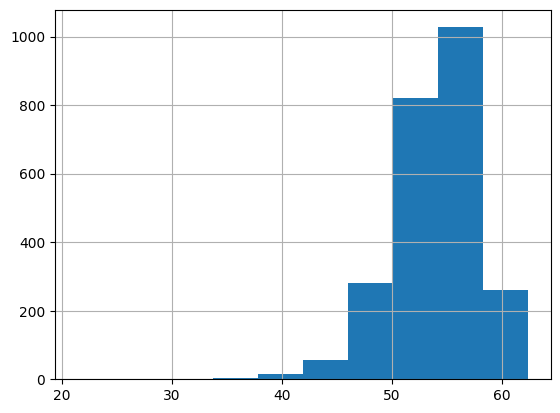

In [30]:
imm['IM_2020'].hist();

La correlación entre las features seleccionadas: 

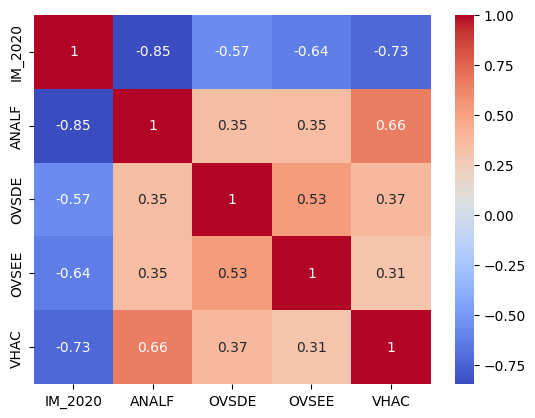

In [43]:
sns.heatmap(imm[imm_features].corr(), annot=True, cmap='coolwarm'); 

* Existe una alta correlación entre las features seleccionadas.

De estas fueatures, podría utilizarse únicamente `IM_2020` ya que posee una alta correlación con las demás features e incluir las demás implicaría información redundante. 

## Censo

In [34]:
censo = pd.read_csv(censo_path)
censo.head()

/tmp/ipykernel_1196/3757157263.py:1: DtypeWarning: Columns (0: ALTITUD) have mixed types. Specify dtype option on import or set low_memory=False.
  censo = pd.read_csv(censo_path)


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,...,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,0,Total nacional,0,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,...,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,0,Total nacional,0,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,...,25581,5027,11306,971,708,8247,10065,29741,5283,*
3,1,Aguascalientes,0,Total de la entidad Aguascalientes,0,Total de la Entidad,NaN,NaN,NaN,1425607,...,359895,236003,174089,98724,70126,6021,15323,128996,1711,*
4,1,Aguascalientes,0,Total de la entidad Aguascalientes,9998,Localidades de una vivienda,NaN,NaN,NaN,3697,...,732,205,212,48,41,39,62,530,20,*


In [35]:
del censo

* Este conjunto de datos ...

## Indicadores de pobreza

El siguiente conjunto de datos posee información sobre pobreza en México a nivel municipal. Las features seleccionadas de este conjunto serán útilies como features explicativas de la variable objetivo.

In [44]:
pobreza = pd.read_csv(pobreza_path, encoding_errors='ignore')
pobreza.head()

,clave_entidad,entidad_federativa,clave_municipio,municipio,poblacion,pobreza_porcentaje,pobreza_poblacion,pobreza_extrema_porcentaje,pobreza_extrema_poblacion,pobreza_moderada_porcentaje,...,fn_carencia_alimentacion_nutritiva_calidad_poblacion,fn_al_menos_una_carencia_porcentaje,fn_al_menos_una_carencia_poblacion,fn_al_menos_tres_carencias_porcentaje,fn_al_menos_tres_carencias_poblacion,fn_ingreso_inferior_a_lpi_porcentaje,fn_ingreso_inferior_a_lpi_poblacion,fn_ingreso_inferior_a_lpei_porcentaje,fn_ingreso_inferior_a_lpei_poblacion,entidad_federativa_etq
0,1,Aguascalientes,1001,Aguascalientes,922268,23.7,218414,2.0,18206,21.7,...,145444.0,51.6,475558.0,7.2,66231.0,33.7,310444.0,9.0,82866.0,Aguascalientes
1,1,Aguascalientes,1002,Asientos,48635,40.1,19518,4.1,2015,36.0,...,13870.0,79.7,38761.0,15.7,7650.0,46.8,22737.0,15.8,7683.0,Aguascalientes
2,1,Aguascalientes,1003,Calvillo,52377,45.8,23966,4.5,2356,41.3,...,10552.0,86.2,45164.0,14.4,7520.0,49.5,25935.0,16.0,8380.0,Aguascalientes
3,1,Aguascalientes,1004,Cosío,15942,37.0,5905,3.4,538,33.7,...,3980.0,69.3,11043.0,10.9,1736.0,47.0,7488.0,16.5,2634.0,Aguascalientes
4,1,Aguascalientes,1005,Jesús María,127962,26.3,33708,3.3,4204,23.1,...,22945.0,59.3,75894.0,11.0,14069.0,34.0,43565.0,10.9,13912.0,Aguascalientes


In [39]:
pobreza.info()

<class 'pandas.DataFrame'>
RangeIndex: 7382 entries, 0 to 7381
Data columns (total 73 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   clave_entidad                                          7382 non-null   int64  
 1   entidad_federativa                                     7382 non-null   str    
 2   clave_municipio                                        7382 non-null   int64  
 3   municipio                                              7382 non-null   str    
 4   poblacion                                              7382 non-null   str    
 5   pobreza_porcentaje                                     7382 non-null   str    
 6   pobreza_poblacion                                      7382 non-null   str    
 7   pobreza_extrema_porcentaje                             7382 non-null   str    
 8   pobreza_extrema_poblacion                              7382

In [45]:
pobreza.columns

Index(['clave_entidad', 'entidad_federativa', 'clave_municipio', 'municipio',
       'poblacion', 'pobreza_porcentaje', 'pobreza_poblacion',
       'pobreza_extrema_porcentaje', 'pobreza_extrema_poblacion',
       'pobreza_moderada_porcentaje', 'pobreza_moderada_poblacion',
       'vulnerable_carencias_sociales_porcentaje',
       'vulnerable_carencias_sociales_poblacion',
       'vulnerable_ingresos_porcentaje', 'vulnerable_ingresos_poblacion',
       'no_pobre_no_vulnerable_porcentaje', 'no_pobre_no_vulnerable_poblacion',
       'carencia_rezago_educativo_porcentaje',
       'carencia_rezago_educativo_poblacion',
       'carencia_servicios_de_salud_porcentaje',
       'carencia_servicios_de_salud_poblacion',
       'carencia_seguridad_social_porcentaje',
       'carencia_seguridad_social_poblacion',
       'carencia_calidad_espacios_vivienda_porcentaje',
       'carencia_calidad_espacios_vivienda_poblacion',
       'carencia_servicios_basicos_vivienda_porcentaje',
       'carencia_se

El total de municipios registrados: 

In [46]:
len(pobreza['clave_municipio'].unique())

2469

* La cantidad total de municipios registrados es similara la de los datasets de incidencia delictiva e indicadores de marginación. No habrá problema al unirlos. 

Consideraremos las siguientes features: 

In [50]:
pobreza_features = [
    'fn_pobreza_porcentaje',  # porcentaje en estado de pobreza
    'fn_pobreza_extrema_porcentaje',  # porcentaje en estado de pobreza severa
    'fn_vulnerable_ingresos_porcentaje',         # porcentaje con ingresos vulnerables
    'fn_carencia_servicios_basicos_vivienda_porcentaje'  # porcentaje con carencia de servicios basicos
]

Las distribuciones: 

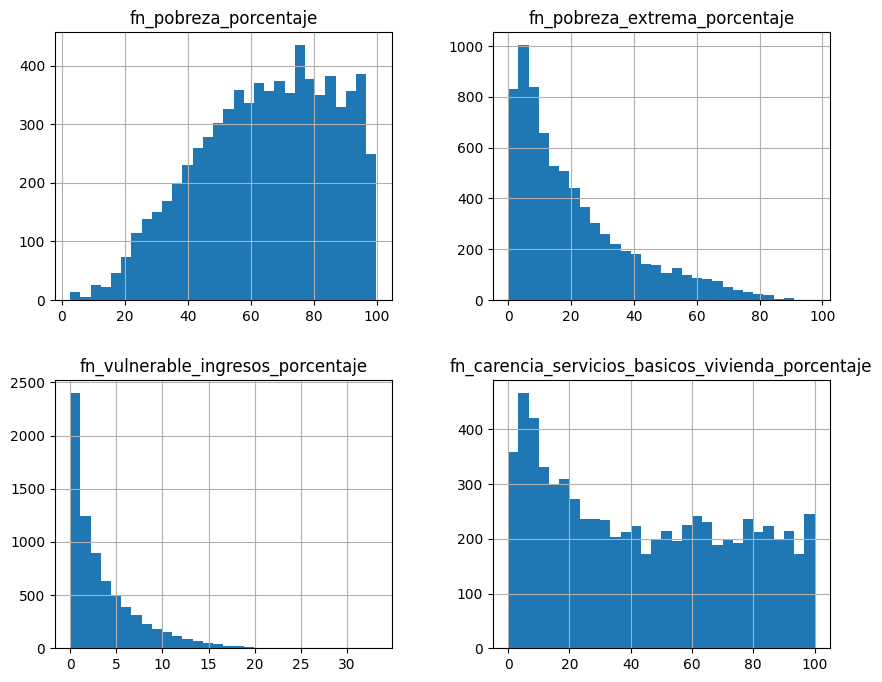

In [51]:
pobreza[pobreza_features].hist(bins=30, figsize=(10, 8));

La correlación entre las features seleccionadas: 

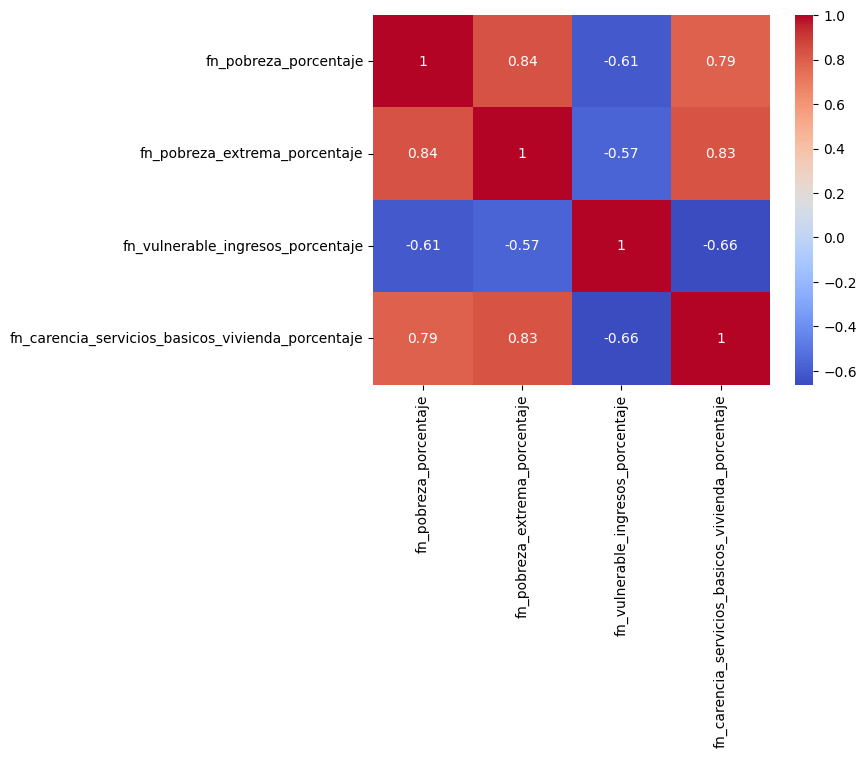

In [52]:
sns.heatmap(pobreza[pobreza_features].corr(), annot=True, cmap='coolwarm'); 

* Las variables seleccionadas poseen alta correlación. 

Valores nulos:

In [53]:
pobreza[pobreza_features].isna().sum()

fn_pobreza_porcentaje                                14
fn_pobreza_extrema_porcentaje                        14
fn_vulnerable_ingresos_porcentaje                    14
fn_carencia_servicios_basicos_vivienda_porcentaje    14
dtype: int64

Eliminamos valores nulos: 

In [54]:
pobreza.dropna(inplace=True)

## Indicadores laborales

In [55]:
laborales = pd.read_csv(laborales_path)
laborales.head()

,ent,mun,est,pea,ocupados,informales
0,0,0,1,59.920,96.568,55.852
1,0,0,2,0.157,0.103,0.254
2,0,0,3,59.662,96.399,55.435
3,0,0,4,60.179,96.738,56.269
4,0,0,5,0.262,0.107,0.454


In [56]:
laborales.info()

<class 'pandas.DataFrame'>
RangeIndex: 12455 entries, 0 to 12454
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ent         12455 non-null  int64  
 1   mun         12455 non-null  int64  
 2   est         12455 non-null  int64  
 3   pea         12455 non-null  float64
 4   ocupados    12455 non-null  float64
 5   informales  12455 non-null  float64
dtypes: float64(3), int64(3)
memory usage: 584.0 KB


In [57]:
laborales.ent.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])

El total de municipios: 

In [58]:
len(laborales.mun.unique())

571

* El total de municipios disponibles en este conjunto de datos es inferior a el total en los otros datasets. Unir los datasets con este conjunto implicaría perder gran cantidad de información. 

De momento será descartado. 

## Joining

Los datos provienen de diferentes fuentes (incidencia delictiva, marginación y pobreza), por lo que es necesario unirlos. 

El dataset principal, indicencia delictiva, fue agregado por municipio-año. Es decir, por cada año y para cada municipio se contabilizaron todos los incidentes delictivos ocurridos. 

El dataset resultado es el siguiente: 

In [93]:
delitos_mun_anual.head()

,anio,cve_ent,cve_mun,ent,mpio,total_anual
0,2015,1,1001,Aguascalientes,Aguascalientes,18800
1,2015,1,1002,Aguascalientes,Asientos,247
2,2015,1,1003,Aguascalientes,Calvillo,554
3,2015,1,1004,Aguascalientes,Coso,160
4,2015,1,1005,Aguascalientes,Jess Mara,1285


Todos los datasets poseen columnas con información sobre la clave de la entidad y clave del municipio. Para evitar ambigüedades en con nombres de municipios debido a encoding, es conveniente construir una clave estandarizada para el joining utilizando estas columnas: 

> cvegeo = clave_entidad + clave_municipio

In [95]:
delitos_mun_anual['cvegeo'] = (
    delitos_mun_anual['cve_ent'].astype(str).str.zfill(2)+
    delitos_mun_anual['cve_mun'].astype(str).str.zfill(3)
)

In [97]:
delitos_mun_anual.head()

,anio,cve_ent,cve_mun,ent,mpio,total_anual,cvegeo
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001
1,2015,1,1002,Aguascalientes,Asientos,247,011002
2,2015,1,1003,Aguascalientes,Calvillo,554,011003
3,2015,1,1004,Aguascalientes,Coso,160,011004
4,2015,1,1005,Aguascalientes,Jess Mara,1285,011005


Para unir los datasets consideraremos un `left join` para perservar todos los municipios con datos de delitos y evitar pérdida de observaciones. 

Los diferentes datasets disponibles se seleccionarion algunas variables. Esta elección inicial fue realizada de manera intiuitiva y orientada a la interpretabilidad.

Dentro del dataset de marginación se seleccinaron las siguientes varibles: 

* `IM_2020`: índice de marginación (indicador global)
* `ANALF`: rezago educativo
* `OVSDE`: falta de drenaje
* `OVSEE`: falta de electricidad
* `VHAC`: hacinamiento
* `PO2SM`: población ocupada con bajos ingresos

Estas variables capturan diferentes dimensiones socioeconomicas:

* educación
* infraestructura
* condiciones de vivienda
* precariedad económica

A continuación se realiza la unión con el conjunto de incidencia delictiva: 

In [102]:
imm['cvegeo'] = (
    imm['CVE_ENT'].astype(str).str.zfill(2) + 
    imm['CVE_MUN'].astype(str).str.zfill(3)  
)

Es importante mencionar que las variables de marginación y pobreza corresponden principalmeente al año 2020. Es decir, estas variables se considerarán estáticas en el tiempo dentro del periodo 2015-2025. 

In [133]:
features_marginacion = [
    'cvegeo',
    'POB_TOT',
    'IM_2020',
    'ANALF',
    'OVSDE',
    'OVSEE',
    'VHAC',
    'PO2SM'
]

In [138]:
df_join_1 = delitos_mun_anual.merge(
    imm[features_marginacion], 
    on='cvegeo', 
    how='left'
)

In [139]:
df_join_1.head()

,anio,cve_ent,cve_mun,ent,mpio,total_anual,cvegeo,POB_TOT,IM_2020,ANALF,OVSDE,OVSEE,VHAC,PO2SM
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001,948990.0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594
1,2015,1,1002,Aguascalientes,Asientos,247,011002,51536.0,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471
2,2015,1,1003,Aguascalientes,Calvillo,554,011003,58250.0,57.058251,4.491509,0.365177,0.516760,19.219858,79.259777
3,2015,1,1004,Aguascalientes,Coso,160,011004,17000.0,57.114030,3.144867,0.712855,0.577354,22.716866,81.726369
4,2015,1,1005,Aguascalientes,Jess Mara,1285,011005,129929.0,59.011762,2.380588,0.277034,0.354957,16.404575,56.748753


Verificamos valores nulos: 

In [140]:
df_join_1.isna().sum()

anio             0
cve_ent          0
cve_mun          0
ent              0
mpio             0
total_anual      0
cvegeo           0
POB_TOT        115
IM_2020        115
ANALF          115
OVSDE          115
OVSEE          115
VHAC           115
PO2SM          115
dtype: int64

* 115 registros nulos.

El dataset de marginación posee más municipios que el dataset de incidencia delictiva, por lo que los valores nulos en el dataset final corresponden a los municipios no registrados en el primero. 

In [141]:
set(delitos_mun_anual['cvegeo']) - set(imm['cvegeo'])

{'022007',
 '044013',
 '099998',
 '1212082',
 '1212083',
 '1212084',
 '1212085',
 '1414998',
 '2020999',
 '2222998',
 '2424059',
 '2525019',
 '2525020',
 '2626998',
 '2626999',
 '3030998',
 '3030999'}

In [142]:
df_join_1['IM_2020'].isna().mean()

np.float64(0.004397201085917486)

En cuanto a las variables de pobreza se seleccionaron las siguientes variables: 

* `fn_pobreza_porcentaje`: pobreza total
* `fn_pobreza_extrema_porcentaje`: pobreza severa
* `fn_vulnerable_ingresos_porcentaje`: vulnerabilidad económica
* `fn_carencia_servicios_basicos_vivienda_porcentaje`: carencias estructurales

Estas variables complementan la marginación al enfocarse en:

* ingreso
* vulnerabilidad
* acceso a servicios

Se evitó incluir variables redundantes (altamente correlacionadas) y conteos absolutos (dependientes de la población). Se priorizaron variables en porcentaje para comparar entre municipios.

In [143]:
pobreza['cvegeo'] = (
    pobreza['clave_entidad'].astype(str).str.zfill(2) + 
    pobreza['clave_municipio'].astype(str).str.zfill(3)
)

In [147]:
features_pobreza = [
    'cvegeo',
    'fn_pobreza_porcentaje',
    'fn_pobreza_extrema_porcentaje',
    'fn_vulnerable_ingresos_porcentaje',
    'fn_carencia_servicios_basicos_vivienda_porcentaje'
]

In [149]:
df_join_2 = df_join_1.merge(
    pobreza[features_pobreza],
    on='cvegeo',
    how='left'
)

In [151]:
df_join_2.head()

,anio,cve_ent,cve_mun,ent,mpio,total_anual,cvegeo,POB_TOT,IM_2020,ANALF,OVSDE,OVSEE,VHAC,PO2SM,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,fn_vulnerable_ingresos_porcentaje,fn_carencia_servicios_basicos_vivienda_porcentaje
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001,948990.0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,23.7,2.0,10.0,1.1
1,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001,948990.0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,26.1,1.6,11.5,3.0
2,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001,948990.0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,30.2,2.2,9.0,3.4
3,2015,1,1002,Aguascalientes,Asientos,247,011002,51536.0,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,40.1,4.1,6.6,7.4
4,2015,1,1002,Aguascalientes,Asientos,247,011002,51536.0,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,54.0,4.4,7.7,16.2


Valores nulos: 

In [152]:
df_join_2.isna().mean()

anio                                                 0.000000
cve_ent                                              0.000000
cve_mun                                              0.000000
ent                                                  0.000000
mpio                                                 0.000000
total_anual                                          0.000000
cvegeo                                               0.000000
POB_TOT                                              0.001476
IM_2020                                              0.001476
ANALF                                                0.001476
OVSDE                                                0.001476
OVSEE                                                0.001476
VHAC                                                 0.001476
PO2SM                                                0.001476
fn_pobreza_porcentaje                                0.001604
fn_pobreza_extrema_porcentaje                        0.001604
fn_vulne

In [153]:
df_join_2['fn_pobreza_porcentaje'].isna().mean()

np.float64(0.0016040035929680483)

**Sobre el dataset de indicadores laborales**

Se evaluó la incorporación del dataset de indicadores laborales (PEA, informalidad, ocupación). Sin embargo, solo cubre \~20\% de los municipios, su inclusión implicaría una perdida significativa de los datos. Por lo tanto, se decició excluir estos indicadores del dataset principal manteniendo la representatividad máxima a nivel nacional. 

No obstante, se identificó la variable `PO2SM` incluida en el dataset de marginación. Esta variable la consideramos como cantidad reprecentativa de las condiciones laborales. 

Conviene cambiar el nombre de las columnas del dataset final: 

In [155]:
df_join_2.columns.tolist()

['anio',
 'cve_ent',
 'cve_mun',
 'ent',
 'mpio',
 'total_anual',
 'cvegeo',
 'POB_TOT',
 'IM_2020',
 'ANALF',
 'OVSDE',
 'OVSEE',
 'VHAC',
 'PO2SM',
 'fn_pobreza_porcentaje',
 'fn_pobreza_extrema_porcentaje',
 'fn_vulnerable_ingresos_porcentaje',
 'fn_carencia_servicios_basicos_vivienda_porcentaje']

In [156]:
cols_final = [
    'anio',
    'cve_ent',
    'cve_mun',
    'ent',
    'mpio',
    'total_incidentes_anual',
    'cvegeo',
    'poblacion_total',
    'indice_marginalidad',
    'analfabetismo',
    'falta_drenaje',
    'falta_electricidad',
    'falta_hacintamiento',
    'bajos_ingresos',
    'pobreza',
    'pobreza_extrema',
    'vulnerable_ingresos',
    'falta_servicios_basicos_vivienda'
]

In [163]:
df_final = df_join_2.set_axis(cols_final, axis=1)

In [165]:
df_final

,anio,cve_ent,cve_mun,ent,mpio,total_incidentes_anual,cvegeo,poblacion_total,indice_marginalidad,analfabetismo,falta_drenaje,falta_electricidad,falta_hacintamiento,bajos_ingresos,pobreza,pobreza_extrema,vulnerable_ingresos,falta_servicios_basicos_vivienda
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001,948990.0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,23.7,2.0,10.0,1.1
1,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001,948990.0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,26.1,1.6,11.5,3.0
2,2015,1,1001,Aguascalientes,Aguascalientes,18800,011001,948990.0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,30.2,2.2,9.0,3.4
3,2015,1,1002,Aguascalientes,Asientos,247,011002,51536.0,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,40.1,4.1,6.6,7.4
4,2015,1,1002,Aguascalientes,Asientos,247,011002,51536.0,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,54.0,4.4,7.7,16.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77925,2025,32,32057,Zacatecas,Trancoso,283,3232057,20455.0,56.958073,5.119108,3.066130,0.500392,23.544577,83.056133,63.1,7.7,7.6,13.7
77926,2025,32,32057,Zacatecas,Trancoso,283,3232057,20455.0,56.958073,5.119108,3.066130,0.500392,23.544577,83.056133,75.7,13.9,3.9,20.7
77927,2025,32,32058,Zacatecas,Santa Mara de la Paz,28,3232058,2767.0,56.055803,5.626223,1.087745,0.471356,17.948717,79.013906,48.0,2.4,7.4,8.4
77928,2025,32,32058,Zacatecas,Santa Mara de la Paz,28,3232058,2767.0,56.055803,5.626223,1.087745,0.471356,17.948717,79.013906,57.4,5.9,2.7,13.2


In [164]:
df_final.to_csv(temp_dir / "dataset_prototype.csv")